# **INIT_COMBINE LOOP SCRIPT**

In [18]:
#STEP 1: IMPORTS
#Load this first

import warnings
import scanpy as sc
import scanpy as sc
import anndata as ad
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import doubletdetection
import soupx
import harmonypy as hm
import decoupler as dc
import scvi
from IPython.display import clear_output 
import re
import os
import time
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

warnings.filterwarnings('ignore')
ad.settings.allow_write_nullable_strings = True
pd.options.future.infer_string = False
pd.reset_option("all")
%matplotlib inline

#COLOR DEFINITIONS
infected_colors = {
    "infected": "#582B36",
    "uninfected": "#582B36"
}


i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)

# marker_genes = {
#     "T Cells": ["Cd3e"],
#     "B Cells": ["Cd19", "Cd74"],
#     "Absorptive Colonocytes": ["Slc26a3","Aqp4","Aqp8","Cyp2c55","Car1"],
#     "Enteroendocrine Cells": ["Neurod1","Chga","Chgb"],
#     "Stem Cells": ["Lgr5","Nox1","Ascl2"],
#     "Transit Amplifying Cells": ["Mki67","Top2a","Ube2c"],
#     "Goblet Cells": ["Muc2","Zg16","Tff3","Spink4"],
#     "Tuft Cells": ["Dclk1"],
#     "Mast Cells": ["Mcpt1","Mcpt2"]
# }
# res_list = [0.20, 0.50, 0.75, 1.00]

In [2]:

cluster_colors = ["#2E5283",
                  "#004100",
                  
                  "#E2552D",
                  
                  "#C67FAE",
                  "#0D199A",
                  "#98DDDF",
                  
                  "#B623CC",
                  "#AC6C29",
                  "#333AFB",
                  "#10BCFE",
                  "#012731",
                  
                  "#F53C9F",
                  "#BAA5FF",
                 "#FCD581"]
#idx 2 = "#582B36",
#idx 4/5 = "#009499","#E3BD33",
#idx 7/8/9 = "#A6BE47","#D7E8BC","#6D5698",
#idx 11 = "#A00239",

In [22]:
# STEP 2: Load Data
#diet_combine = sc.read_h5ad("data/20260731_diet_reannotated.h5ad")
#live_redo = sc.read_h5ad("data/20260731_live_reannotated.h5ad")
diet_combine = sc.read_h5ad("/projects/hvose@xsede.org/adata_filtered_files/20260604_diet_adata_soupx_refiltered.h5ad")

In [26]:
print(diet_combine.obs.dtypes)
#sc.pl.umap(diet_combine,color="")

sample                         category
treatment                      category
leiden                         category
n_genes_by_counts                 int64
log1p_n_genes_by_counts         float64
total_counts                    float64
log1p_total_counts              float64
pct_counts_in_top_50_genes      float64
pct_counts_in_top_100_genes     float64
pct_counts_in_top_200_genes     float64
pct_counts_in_top_500_genes     float64
total_counts_mt                 float64
log1p_total_counts_mt           float64
pct_counts_mt                   float64
n_genes                           int64
doublet_score                   float64
predicted_doublet                  bool
dtype: object


In [17]:
for val in range(1,17):
    match val:
            case val if 1<=int(val)<=5:
                diet_combine.obs.loc[diet_combine.obs["sample"] == f"sample_{val}", 'treatment'] = 'no_fiber'
            case val if 6<=int(val)<=10:
                diet_combine.obs.loc[diet_combine.obs["sample"] == f"sample_{val}", 'treatment'] = 'amp'
            case _:
                diet_combine.obs.loc[diet_combine.obs["sample"] == f"sample_{val}", 'treatment'] = '3DPI'

In [ ]:
for val in range(1,4):
    live_redo.obs.loc[live_redo.obs["sample"] == f"MHVY_Colon_5dpi_{val}", 'treatment'] = '5DPI'
    live_redo.obs.loc[live_redo.obs["sample"] == f"Uninfected_{val}", 'treatment'] = 'Mock'

In [ ]:
print(diet_combine.obs.dtypes)
#print(live_redo.obs.dtypes)

In [ ]:
for col in diet_combine.obs.select_dtypes(include=["string"]).columns:
    diet_combine.obs[col] = diet_combine.obs[col].astype(object)

## **Cluster Labeling**

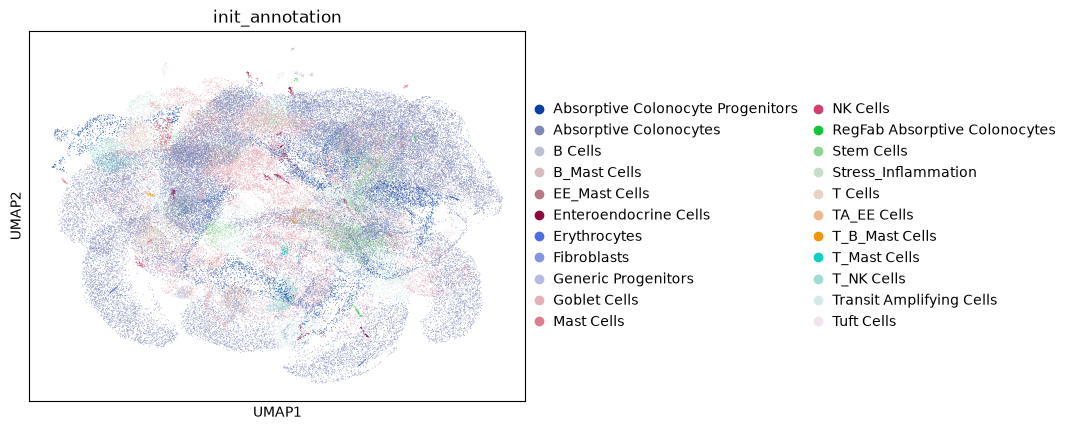

In [8]:
sc.pl.umap(diet_combine, color="init_annotation")

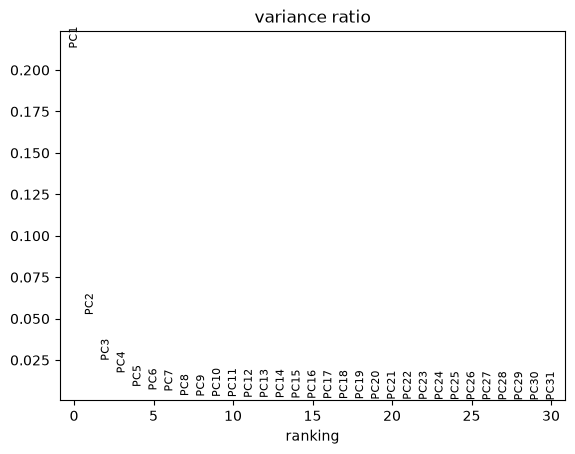

2026-08-20 21:03:25,542 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-08-20 21:03:25,544 - harmonypy - INFO -   Parameters:
2026-08-20 21:03:25,544 - harmonypy - INFO -     max_iter_harmony: 25
2026-08-20 21:03:25,544 - harmonypy - INFO -     max_iter_kmeans: 20
2026-08-20 21:03:25,545 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-08-20 21:03:25,545 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-08-20 21:03:25,545 - harmonypy - INFO -     nclust: 100
2026-08-20 21:03:25,546 - harmonypy - INFO -     block_size: 0.05
2026-08-20 21:03:25,546 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-08-20 21:03:25,547 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-08-20 21:03:25,547 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-20 21:03:25,547 - harmonypy - INFO -     verbose: True
2026-08-20 21:03:25,548 - harmonypy - INFO -     random_state: 0
2026-08-20 21:03:25,548 - harmon

finished harmony


In [9]:
# STEP 3: Get PCs and batch unmix the data
#sc.pp.pca(live_redo)
sc.pp.pca(diet_combine)
sc.pl.pca_variance_ratio(diet_combine)
#pcs_l = live_redo.obsm['X_pca']
pcs_d = diet_combine.obsm['X_pca']
#print(pcs.shape)  # (n_cells, n_pcs)

# Run Harmony on the PCA embedding
#harmony_out_l = hm.run_harmony(pcs_l, live_redo.obs, "sample",max_iter_harmony=25)
harmony_out_d = hm.run_harmony(pcs_d, diet_combine.obs, "sample",max_iter_harmony=25)


print("finished harmony")

# Store corrected PCs back in the AnnData object
#live_redo.obsm['X_pca_harmony'] = harmony_out_l.Z_corr
diet_combine.obsm['X_pca_harmony'] = harmony_out_d.Z_corr
#sc.pp.neighbors(live_redo, use_rep='X_pca_harmony')
sc.pp.neighbors(diet_combine, use_rep='X_pca_harmony')
#sc.tl.umap(live_redo)
sc.tl.umap(diet_combine)

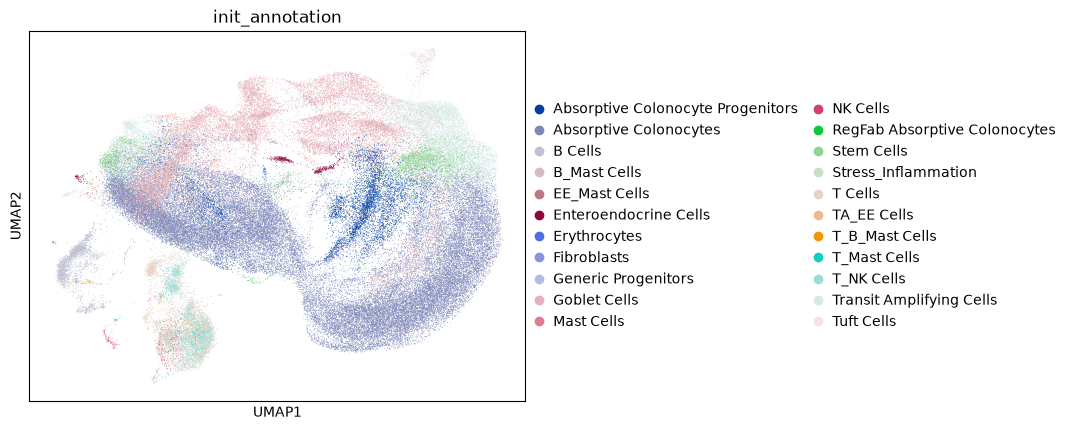

In [10]:
sc.pl.umap(diet_combine, color="init_annotation")

In [ ]:
#plot hell pt 2 electric boogaloo
#sc.pl.umap(live_redo, color=["sample","init_annotation"])
#sc.pl.umap(diet_combine, color="Clca1",cmap=ifitm_cmap,frameon=False,title="",save="clca1_diet_all_conditions.svg")
#sc.pl.umap(diet_combine, color="Clca1",mask_obs=diet_combine.obs["treatment"]=="3DPI",frameon=False,title="",cmap=ifitm_cmap,save="clca1_diet_only_3dpi.svg")
#sc.pl.umap(diet_combine,color="init_annotation",palette=cluster_colors,frameon=False,title="",save="diet_all_clusters.svg")

#sc.pl.umap(live_redo,color="cluster_cell_type",palette=cluster_colors,frameon=False,title="",save="live_all_clusters.svg")
sc.pl.umap(live_redo, color="Clca1",cmap=ifitm_cmap,frameon=False,title="",save="clca1_live_all_conditions.svg")
sc.pl.umap(live_redo, color="Clca1",mask_obs=live_redo.obs["treatment"]=="5DPI",frameon=False,title="",cmap=ifitm_cmap,save="clca1_live_only_3dpi.svg")

In [ ]:
#generate a DEG list of a specific cluster comparing two specific treatments
diet_clusters = diet_combine.obs["init_annotation"].cat.categories.tolist()
live_clusters = live_redo.obs["cluster_cell_type"].cat.categories.tolist()

combined_vals = []
mhvy_only_vals = []
dhe_only_vals = []

amp_overlap = []
nf_overlap = []
total_overlap = []

with open("20260820_diet_live_DEG_per_cluster_reverse.txt","w",encoding="utf-8") as f:
    for vclus in diet_clusters:
        print(diet_combine[diet_combine.obs["init_annotation"] == vclus].obs["treatment"].value_counts())
        if diet_combine[diet_combine.obs["init_annotation"] == vclus].obs["treatment"].cat.categories.tolist() != ["3DPI","amp","fiber"]:
            print(f"NO CALCULATION FOR {vclus}, MISSING VALUES")
            f.write(f"NO CALCULATION FOR {vclus}, MISSING VALUES")
        else:
            curr_diet_nf = diet_combine[(diet_combine.obs["treatment"].isin(["fiber","3DPI"])) & (diet_combine.obs["init_annotation"] == vclus)]
            curr_diet_amp = diet_combine[(diet_combine.obs["treatment"].isin(["amp","3DPI"])) & (diet_combine.obs["init_annotation"] == vclus)]
            sc.tl.rank_genes_groups(curr_diet_nf, groupby="treatment", method='wilcoxon',reference="fiber",key_added=f"diet_nf_vs_mhvy_{vclus}")
            sc.tl.rank_genes_groups(curr_diet_amp, groupby="treatment", method='wilcoxon',reference="amp",key_added=f"diet_amp_vs_mhvy_{vclus}")
            df_diet_nf = sc.get.rank_genes_groups_df(curr_diet_nf, group="3DPI",key=f"diet_nf_vs_mhvy_{vclus}")
            df_diet_amp = sc.get.rank_genes_groups_df(curr_diet_amp, group="3DPI",key=f"diet_amp_vs_mhvy_{vclus}")
        
            sig_df_diet_amp_up = df_diet_amp[(df_diet_amp['pvals_adj'] < 0.05) & (df_diet_amp['logfoldchanges'] > 0)]
            sig_df_diet_amp_dw = df_diet_amp[(df_diet_amp['pvals_adj'] < 0.05) & (df_diet_amp['logfoldchanges'] < 0)]
            sig_df_diet_nf_up = df_diet_nf[(df_diet_nf['pvals_adj'] < 0.05) & (df_diet_nf['logfoldchanges'] > 0)]
            sig_df_diet_nf_dw = df_diet_nf[(df_diet_nf['pvals_adj'] < 0.05) & (df_diet_nf['logfoldchanges'] < 0)]
        
            #diet_combined_up = sig_df_diet_nf_up.loc[(sig_df_diet_nf_up['names'].isin(sig_df_diet_amp_up['names']))]
            diet_dhe_overlap_up = sig_df_diet_nf_up.loc[(sig_df_diet_nf_up['names'].isin(sig_df_diet_amp_up['names']))]
            diet_dhe_overlap_dw = sig_df_diet_nf_dw.loc[(sig_df_diet_nf_dw['names'].isin(sig_df_diet_amp_dw['names']))]
            #diet_dhe_combined = diet_dhe_amp_overlap_up.loc[(diet_dhe_amp_overlap_up['names'].isin(diet_dhe_nf_overlap_up['names']))]
        
            # amp_nf_up_overlap = sig_df_diet_amp_up.loc[(sig_df_diet_amp_up['names'].isin(sig_df_diet_nf_up['names']))]
            # amp_nf_dw_overlap = sig_df_diet_nf_dw.loc[(sig_df_diet_nf_dw['names'].isin(sig_df_diet_amp_dw['names']))]
            # amp_nf_dhe_overlap = amp_nf_up_overlap.loc[(amp_nf_up_overlap['names'].isin(vg_dhe_up_only['names']))]
            # amp_nf_dhe_dw_overlap = amp_nf_dw_overlap.loc[(amp_nf_dw_overlap['names'].isin(vg_dhe_dw_only['names']))]
        
            f.write(f"DIET CLUSTER {vclus}:\n")
            f.write(f"Out of {len(sig_df_diet_amp_up)} total amp-up genes, {len(sig_df_diet_amp_dw)} total amp-down genes, {len(sig_df_diet_nf_up)} total no fiber-up genes, and {len(sig_df_diet_nf_dw)} total no fiber-down \n")
            # f.write(f"COMBINED UPREGULATED: {len(diet_combined_up['names'])}")
            # f.write(diet_combined_up['names'].tolist())
            #f.write(f"\n{vclus} OVERLAP UP: {len(diet_dhe_overlap_up['names'])}\n")
            #f.write(str(diet_dhe_overlap_up['names'].tolist()))
            #f.write(f"\n{vclus} OVERLAP DW: {len(diet_dhe_overlap_dw['names'])}\n")
            #f.write(str(diet_dhe_overlap_dw['names'].tolist()))
            f.write(f"\n{vclus} NO FIBER UP\n")
            f.write(str(sig_df_diet_nf_up['names'].tolist()))
            f.write(f"\n{vclus} NO FIBER DW\n")
            f.write(str(sig_df_diet_nf_dw['names'].tolist()))
            f.write(f"\n{vclus} AMP UP\n")
            f.write(str(sig_df_diet_amp_up['names'].tolist()))
            f.write(f"\n{vclus} AMP DW\n")
            f.write(str(sig_df_diet_amp_dw['names'].tolist()))
            # f.write(f"TOTAL dHE OVERLAP: {len(diet_dhe_combined['names'])}")
            # f.write(diet_dhe_combined['names'].tolist())
            # f.write(f"TOTAL AMP NF OVERLAP UP: {len(amp_nf_up_overlap['names'])}")
            # f.write(amp_nf_up_overlap['names'].tolist())
            # f.write(f"TOTAL AMP NF OVERLAP DW: {len(amp_nf_dw_overlap['names'])}")
            # f.write(amp_nf_dw_overlap['names'].tolist())
            # f.write(f"ALL DW OVERLAP: {len(amp_nf_dhe_dw_overlap['names'])}")
            # f.write(amp_nf_dhe_dw_overlap['names'].tolist())
                
    for vclus in live_clusters:
        print(live_redo[live_redo.obs["cluster_cell_type"] == vclus].obs["treatment"].value_counts())
        if live_redo[live_redo.obs["cluster_cell_type"] == vclus].obs["treatment"].cat.categories.tolist() != ["5DPI","Mock"]:
            print(f"NO CALCULATION FOR {vclus}, MISSING VALUES")
            f.write(f"NO CALCULATION FOR {vclus}, MISSING VALUES")
        else:
            live_clus = live_redo[(live_redo.obs["treatment"].isin(["Mock","5DPI"])) & (live_redo.obs["cluster_cell_type"] == vclus)]
            sc.tl.rank_genes_groups(live_clus, groupby="treatment", method='wilcoxon',reference="Mock",key_added=f"live_{vclus}")
            df_live = sc.get.rank_genes_groups_df(live_clus, group="5DPI",key=f"live_{vclus}")
            sig_df_live_up = df_live[(df_live['pvals_adj'] < 0.05) & (df_live['logfoldchanges'] > 0)]
            sig_df_live_dw = df_live[(df_live['pvals_adj'] < 0.05) & (df_live['logfoldchanges'] < 0)]
        
            f.write(f"LIVE CLUSTER {vclus}:\n")
            f.write(f"\n{vclus} 5DPI UP (MOCK DW): {len(sig_df_live_up['names'])}\n")
            f.write(str(sig_df_live_up['names'].tolist()))
            f.write(f"\n{vclus} 5DPI DW (MOCK UP): {len(sig_df_live_dw['names'])}\n")
            f.write(str(sig_df_live_dw['names'].tolist()))
        
    # a_title = "dhe_vs_mhvy_b.csv"
    # current_clus.to_csv(a_title,index=False)

In [ ]:
sc.pp.highly_variable_genes(
    diet_combine, n_top_genes=4000, flavor="seurat_v3", subset=False, layer="counts"
)
# sc.pp.highly_variable_genes(
#     live_redo, n_top_genes=4000, flavor="seurat_v3", subset=False, layer="counts"
# )

In [ ]:
res_list = [0.20,0.50,0.75,1.00,1.50,2.00,2.50]

for res in res_list:
    print(f"now calculating leiden res {res}")
    sc.tl.leiden(diet_combine, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")
    #sc.tl.leiden(live_redo, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

In [ ]:

sc.pl.umap(
    diet_combine,
    color=["leiden_res_0.20", "leiden_res_0.50", "leiden_res_0.75", "leiden_res_1.00", "leiden_res_1.50","leiden_res_2.00","leiden_res_2.50"],
    legend_loc="on data",
)

In [ ]:
sc.pl.umap(
    live_redo,
    color=["leiden_res_0.50", "leiden_res_0.75", "leiden_res_1.00", "leiden_res_1.50","leiden_res_2.00","leiden_res_2.50"],
    legend_loc="on data",
)

In [ ]:
see_view = "0.75"
markers = ["Cd3e","Cd74","Slc26a3", "Aqp4", "Aqp8", "Cyp2c55", "Car1", "Chga", "Muc2", "Tff3", "Spink4", "Zg16", "Lgr5", "Ascl2", "Nox1", "Mki67", "Top2a", "Ube2c", "Dclk1"]
sc.tl.rank_genes_groups(diet_combine, groupby=f"leiden_res_{see_view}", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(diet_combine, groupby=f"leiden_res_{see_view}", standard_scale="var", n_genes=5,dendrogram=False)
sc.pl.heatmap(diet_combine,markers,groupby=f"leiden_res_{see_view}",figsize=(30,8),swap_axes=True)
sc.pl.umap(diet_combine,color=f"leiden_res_{see_view}",legend_loc="on data")

In [ ]:
markers = ["Cd3e","Cd74","Slc26a3", "Aqp4", "Aqp8", "Cyp2c55", "Car1", "Thbs4", "Ckmt1", "Hoxb13", "Chga", "Muc2", "Tff3", "Spink4", "Zg16", "Lgr5", "Ascl2", "Nox1", "Mki67", "Top2a", "Ube2c", "Dclk1"]
sc.pl.umap(diet_combine,color=markers)

In [ ]:
sc.pl.umap(diet_combine, color="init_annotation",size=20,mask_obs=(diet_combine.obs["leiden_res_2.00"] == "47"))

In [ ]:
#vague annotations - does NOT need to be highly specific

cluster2annotation = {
    "0": "Goblet Cells",
    "1": "Stem Cells",
    "2": "Goblet Cells",
    "3": "Absorptive Colonocytes",
    "4": "Goblet Cells",
    "5": "Goblet Cells",
    "6": "Goblet Cells",
    "7": "Absorptive Colonocytes",
    "8": "Immune Cells",
    "9": "Transit Amplifying Cells",
    "10": "Absorptive Colonocytes",
    "11": "Absorptive Colonocyte Progenitors",
    "12": "Goblet Cells",
    "13": "Goblet Cells",
    "14": "Transit Amplifying Cells",
    "15": "Absorptive Colonocytes",
    "16": "Absorptive Colonocytes",
    "17": "Enteroendocrine Cells",
    "18": "Absorptive Colonocytes",
    "19": "Transit Amplifying Cells",
    "20": "Goblet Cells",
    "21": "Goblet Cells",
    "22": "Absorptive Colonocytes",
    "23": "Goblet Cells",
    "24": "Goblet Cells",
    "25": "Stem Cells",
    "26": "Goblet Cells",
    "27": "Goblet Cells",
    "28": "Absorptive Colonocytes",
    "29": "Transit Amplifying Cells",
    "30": "Stem Cells",
    "31": "Transit Amplifying Cells",
    "32": "Goblet Cells",
    "33": "Tuft Cells",
    "34": "Goblet Cells",
    "35": "Goblet Cells",
    "36": "Enteroendocrine Cells",
    "37": "Absorptive Colonocytes",
    "38": "Immune Cells",
}

live_redo.obs['cluster_cell_type'] = live_redo.obs["leiden_res_2.00"].map(cluster2annotation).astype('category')

cluster2annotation_d = {
    "0": "Absorptive Colonocytes",
    "1": "Absorptive Colonocytes",
    "2": "Goblet Cells",
    "3": "Stem Cells",
    "4": "T Cells",
    "5": "Transit Amplifying Cells",
    "6": "Tuft Cells",
    "7": "Transit Amplifying Cells",
    "8": "Goblet Cells",
    "9": "Absorptive Colonocytes",
    "10": "Goblet Cells",
    "11": "B Cells",
    "12": "T Cells",
    "13": "Absorptive Colonocyte Progenitors",
    "14": "Goblet Cells",
    "15": "Absorptive Colonocyte Progenitors",
    "16": "Absorptive Colonocytes",
    "17": "Absorptive Colonocytes",
    "18": "Absorptive Colonocytes",
    "19": "Absorptive Colonocytes",
    "20": "Transit Amplifying Cells",
    "21": "Absorptive Colonocytes",
    "22": "Absorptive Colonocytes",
    "23": "Absorptive Colonocytes",
    "24": "T Cells",
    "25": "Absorptive Colonocytes",
    "26": "Enteroendocrine Cells",
    "27": "Goblet Cells",
    "28": "Absorptive Colonocytes",
    "29": "B Cells",
    "30": "T Cells",
    "31": "Absorptive Colonocytes",
    "32": "Goblet Cells",
    "33": "Goblet Cells",
    "34": "T Cells",
    "35": "Absorptive Colonocytes",
    "36": "Absorptive Colonocytes",
    "37": "Absorptive Colonocytes",
    "38": "Mast Cells",
    "39": "Tuft Cells",
    "40": "Enteroendocrine Cells",
    "41": "Transit Amplifying Cells",
    "42": "Absorptive Colonocyte Progenitors",
    "43": "Goblet Cells",
    "44": "Absorptive Colonocytes",
    "45": "RegFab Absorptive Colonocytes",
    "46": "Transit Amplifying Cells",
    "47": "Goblet/AC Mix"
}

diet_combine.obs['cluster_cell_type'] = diet_combine.obs["leiden_res_2.00"].map(cluster2annotation_d).astype('category')

In [ ]:
sc.pl.umap(diet_combine, color=["init_annotation","cluster_cell_type"])

In [ ]:
sc.pl.umap(live_redo, color=["init_annotation"])

In [ ]:
sc.pl.umap(live_redo,
           color=["init_annotation"],
           mask_obs=((live_redo.obs["init_annotation"] == "T_NK Cells") & (live_redo.obs["leiden_res_2.00"] == "47")),size=20)


In [ ]:
#reassignment block

live_redo.obs.loc[(live_redo.obs["init_annotation"] == "Stress_Inflamed"), "init_annotation"] = "Absorptive Colonocytes"

### Attempting to remove categories

In [ ]:
# print the cluster cell type of all remaining barcodes that are present in the init_annotation category, as well as specific gene expression values
print(live_redo.obs.loc[((live_redo.obs["init_annotation"] == "Stress_Inflamed")), ["leiden_res_2.00","cluster_cell_type"]])

sub_df = sc.get.obs_df(live_redo[live_redo.obs["init_annotation"] == "Stress_Inflamed"],keys=["Muc2","Car1","Nox1","Lgr5","leiden_res_2.00"])

In [ ]:
#reassignment block by loop

for idx, row in sub_df.iterrows():
    #print(f"{idx} and row is {row}")
    #print(f"is {row["Muc2"]} greater than {row["Car1"]}")
    if float(row["Muc2"]) > float(row["Car1"]):
        #print("should be gob")
        live_redo.obs.at[idx, "init_annotation"] = "Goblet Cells"
        #print(live_redo[idx].obs["init_annotation"])
    else:
        #print("should be ac")
        live_redo.obs.at[idx, "init_annotation"] = "Absorptive Colonocytes"
        #print(live_redo[idx].obs["init_annotation"])

In [ ]:
#attempt to remove empty categories
diet_combine.obs["init_annotation"].cat.categories

In [ ]:
#reassign newly removed categories to initial object

live_redo.obs["init_annotation"] = live_redo.obs["init_annotation"].cat.remove_unused_categories()

In [ ]:
#second writing block (post-combine)

live_redo.write_h5ad("20260731_live_reannotated.h5ad")
diet_combine.write_h5ad("20260731_diet_reannotated.h5ad")

In [ ]:
aggregated

In [ ]:
all_vars = list(my_var.upper() for my_var in diet_combine.var_names)

for var_name in all_vars:
    il_match = re.search(f"H2-",var_name)
    if il_match is not None:
        try:
            sc.pl.umap(diet_combine, color=var_name,frameon=False)
        except KeyError as e:
            print(f"idk why but {var_name} isn't here")

In [ ]:
# 1. Calculate the mean expression per cluster
# Replace 'leiden' with your specific cluster column name (e.g., 'louvain', 'cell_type')
aggregated = sc.get.aggregate(diet_combine, by="init_annotation", func="mean")

print(aggregated.layers['mean'])

# 2. Extract into a clean, readable Pandas DataFrame
# Rows will be clusters, columns will be genes
df_mean_expr = sc.get.obs_df(aggregated)

# 3. Transpose if you prefer genes as rows and clusters as columns
df_mean_expr = df_mean_expr.T
print(df_mean_expr.head())

In [ ]:
sc.pl.umap(diet_combine, color=["treatment"])

In [ ]:
for gene in ifng_genes:
    try:
        sc.pl.umap(diet_combine, color=gene, mask_obs=(diet_combine.obs["treatment"]=="fiber"))
    except KeyError as e:
        print(f"{gene} not present")

In [ ]:
#sc.pl.umap(diet_combine, color="Icam1")

## **Pseudobulking and Differential Gene Expression**

In [ ]:
pdata_diet = dc.pp.pseudobulk(
    diet_combine,
    sample_col='sample',
    groups_col='treatment',
    layer='counts',
    mode='sum'
)

In [ ]:
pdata_live = dc.pp.pseudobulk(
    live_redo,
    sample_col='treatment',
    groups_col='cluster_cell_type',
    layer='counts',
    mode='sum'
)

In [ ]:
print(pdata_diet)
print(pdata_live)

In [ ]:
print(pdata_diet.obs["psbulk_counts"].value_counts())

In [ ]:
dc.pl.filter_samples(pdata_diet,
                     groupby=['treatment', 'init_annotation'],
                     figsize=(12, 12),
                     min_cells=10,
                     min_counts=1000)

In [ ]:
dc.pl.filter_samples(pdata_live,
                     groupby=['treatment', 'cluster_cell_type'],
                     figsize=(12, 12),
                     min_cells=10,
                     min_counts=1000)

In [ ]:
dc.pp.filter_samples(pdata_diet, min_cells=10, min_counts=1000, inplace=True)

In [ ]:
# Store raw counts in layers
pdata_live.layers["counts"] = pdata_live.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata_live, target_sum=1e4)
sc.pp.log1p(pdata_live)
sc.pp.scale(pdata_live, max_value=10)
sc.tl.pca(pdata_live)

# Return raw counts to X
dc.pp.swap_layer(adata=pdata_live, key="counts", inplace=True)

In [ ]:
# Store raw counts in layers
pdata_diet.layers["counts"] = pdata_diet.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata_diet, target_sum=1e4)
sc.pp.log1p(pdata_diet)
sc.pp.scale(pdata_diet, max_value=10)
sc.tl.pca(pdata_diet)

# Return raw counts to X
dc.pp.swap_layer(adata=pdata_diet, key="counts", inplace=True)

In [ ]:
dc.tl.rankby_obsm(pdata_live,key='X_pca',obs_keys=["init_annotation"])

In [ ]:
print(pdata_diet.obs["treatment"].value_counts())

In [ ]:
#dc.pl.obsm(adata=pdata_diet, return_fig=True, nvar=5, titles=["PC scores", "Adjusted p-values"], figsize=(10, 5))

sc.pl.pca(
    pdata_diet,
    color=["treatment", "init_annotation"],
    ncols=1,
    size=300,
    frameon=True,
)

sc.pl.pca(
    pdata_live,
    color=["treatment", "cluster_cell_type"],
    ncols=1,
    size=300,
    frameon=True,
)

In [ ]:
# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=pdata_live,
    design="~treatment",
    refit_cooks=True,
    inference=inference,
)

# Compute LFCs
dds.deseq2()

# Extract contrast between conditions
stat_res = DeseqStats(dds, contrast=["treatment","5DPI","Mock"], inference=inference)
stat_res.summary()
#stat_res_a = DeseqStats(dds, contrast=["treatment","fiber","amp"], inference=inference)

# Compute Wald test
#output_f = stat_res_f.summary()
#output_a = stat_res_a.summary()

In [ ]:
# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=pdata_diet,
    design="~treatment",
    refit_cooks=True,
    inference=inference,
)

# Compute LFCs
dds.deseq2()

# Extract contrast between conditions
stat_res_f = DeseqStats(dds, contrast=["treatment","fiber","3DPI"], inference=inference)
stat_res_f.summary()
stat_res_a = DeseqStats(dds, contrast=["treatment","amp","3DPI"], inference=inference)
stat_res_a.summary()
stat_res_both = DeseqStats(dds, contrast=["treatment","fiber","amp"], inference=inference)
stat_res_both.summary()

In [ ]:
output_f = stat_res_f.results_df[['log2FoldChange','padj']].sort_values(by='padj')
output_a = stat_res_a.results_df[['log2FoldChange','padj']].sort_values(by='padj')
output_both = stat_res_both.results_df[['log2FoldChange','padj']].sort_values(by='padj')
output_f.to_csv("fiber_vs_5dpi_DEG.csv")
output_a.to_csv("amp_vs_5dpi_DEG.csv")


In [ ]:
stat_res_f.results_df.loc["Ifit3"]
#print(stat_res.results_df["padj"])

In [ ]:
stat_res.results_df[['log2FoldChange','padj']].sort_values(by='padj').to_csv("Mock_vs_5DPI_scRNA_DEG.csv")

In [ ]:
#volcano plots of differential genes

dc.pl.volcano(stat_res_f.results_df, x="log2FoldChange", y="pvalue")
dc.pl.volcano(stat_res_a.results_df, x="log2FoldChange", y="pvalue")
dc.pl.volcano(stat_res_both.results_df, x="log2FoldChange", y="pvalue")

## **GSEA and Transcription Factor ORA**

In [ ]:
#Load dataset of transcription factors to use
collectri = dc.op.collectri(organism="mouse")
hallmark = dc.op.hallmark(organism="mouse")
hallmark

In [ ]:
live_data = stat_res.results_df[["stat"]].T.rename(index={"stat": "5dpi.vs.mock"})
live_data_p = stat_res.results_df[["padj"]]
print(live_data_p)
valid_genes = []

for gene in live_data.columns.tolist():
    if gene in ifna_genes:
        if gene in ifng_genes:
            print(f"{gene}: {live_data[gene]["5dpi.vs.mock"]} in both")
        else:
            print(f"{gene}: {live_data[gene]["5dpi.vs.mock"]} only in ifna")
        valid_genes.append(gene)
    else:
        if gene in ifng_genes:
            print(f"{gene}: {live_data[gene]["5dpi.vs.mock"]} only in ifng")
            valid_genes.append(gene)

print(valid_genes)

for genea in ifna_genes:
    if genea not in valid_genes:
        ifna_genes.remove(genea)

for geneg in ifng_genes:
    if geneg not in valid_genes:
        ifng_genes.remove(geneg)

print(f"ifng: {ifng_genes}")
print(f"ifna: {ifna_genes}")

In [ ]:
diet_f_data = stat_res_f.results_df[["stat"]].T.rename(index={"stat": "fiber.vs.3dpi"})
diet_f_data_p = stat_res_f.results_df[["padj"]].T.rename(index={"padj": "fiber.vs.3dpi"})
print(diet_f_data_p)
diet_a_data = stat_res_a.results_df[["stat"]].T.rename(index={"stat": "amp.vs.3dpi"})
diet_both_data = stat_res.results_df[["stat"]].T.rename(index={"stat": "fiber.vs.amp"})

prefixes = [diet_f_data,diet_a_data,diet_both_data]

valid_genes = []

for gene in diet_f_data_p.columns.tolist():
    mhc_match = re.search("H2-",gene)
    #if gene in ifna_genes:
    if mhc_match is not None:
        #if gene in ifng_genes:
        if float(diet_f_data_p[gene]["fiber.vs.3dpi"]) < 0.05:
            print(f"{gene}: {diet_f_data_p[gene]["fiber.vs.3dpi"]} in both")
            valid_genes.append(gene)
    #     else:
    #         if float(diet_f_data_p[gene]["fiber.vs.3dpi"]) < 0.05:
    #             print(f"{gene}: {diet_f_data_p[gene]["fiber.vs.3dpi"]} only in ifna")
    #             valid_genes.append(gene)
    # else:
    #     if gene in ifng_genes:
    #         if float(diet_f_data_p[gene]["fiber.vs.3dpi"]) < 0.05:
    #             print(f"{gene}: {diet_f_data_p[gene]["fiber.vs.3dpi"]} only in ifng")
    #             valid_genes.append(gene)

print(valid_genes)

# for genea in ifna_genes:
#     if genea not in valid_genes:
#         ifna_genes.remove(genea)

# for geneg in ifng_genes:
#     if geneg not in valid_genes:
#         ifng_genes.remove(geneg)

# print(f"ifng: {ifng_genes}")
# print(f"ifna: {ifna_genes}")

diet_tf_dict = {}

In [ ]:
# Run

for idx, prefix in enumerate(prefixes):
    curr_tf, curr_padj = dc.mt.ulm(data=prefix, net=collectri)
    msk = (curr_padj.T < 0.05).iloc[:,0]
    curr_padj = curr_padj.loc[:,msk]
    diet_tf_dict[idx] = [curr_tf, curr_padj]

In [ ]:
dc.pl.barplot(data=live_data,name="5dpi.vs.mock",figsize=(4,6))
plt.title("live")

In [ ]:
%matplotlib inline
for keys, vals in diet_tf_dict.items():
    match keys:
        case 0:
            dc.pl.barplot(data=vals[1], name="fiber.vs.3dpi", figsize=(4, 3))
            plt.title("3dpi vs fiber")
        case 1:
            dc.pl.barplot(data=vals[1], name="amp.vs.3dpi", figsize=(4, 6))
            plt.title("3dpi vs amp")
        case 2:
            dc.pl.barplot(data=vals[1], name="fiber.vs.amp", figsize=(4, 3))
            plt.title("fiber vs amp")
    

In [ ]:
dc.pl.network(
    net=collectri,
    data=diet_f_data,
    score=diet_tf_dict[0][1],
    sources=["Ppara","E2f2","E2f1","Hnf1a"],
    targets=5,
    figsize=(10, 5),
    vcenter=True,
    by_abs=True,
    size_node=15,
    t_label="Gene-level\nstatistic",
)

In [ ]:
dc.pl.volcano(
    data=stat_res_f.results_df,
    x="log2FoldChange",
    y="pvalue",
    net=collectri,
    name="Ppara",
    top=10,
)

In [ ]:
#dc.op.show_resources() #use to see all available options for database pathway scoring
# Run
hm_acts, hm_padj = dc.mt.ulm(data=live_data, net=hallmark)

# Filter by sign padj
msk = (hm_padj.T < 0.05).iloc[:, 0]
hm_acts = hm_acts.loc[:, msk]

hm_acts

In [ ]:
#dc.op.show_resources() #use to see all available options for database pathway scoring
# Run
hm_acts_f, hm_padj_f = dc.mt.ulm(data=diet_f_data, net=hallmark)
# Filter by sign padj
hm_acts_f = hm_acts_f.loc[:, (hm_padj_f.T < 0.05).iloc[:, 0]]

# Run
hm_acts_a, hm_padj_a = dc.mt.ulm(data=diet_a_data, net=hallmark)
# Filter by sign padj
hm_acts_a = hm_acts_a.loc[:, (hm_padj_a.T < 0.05).iloc[:, 0]]

# Run
hm_acts_both, hm_padj_both = dc.mt.ulm(data=diet_both_data, net=hallmark)
# Filter by sign padj
hm_acts_both = hm_acts_both.loc[:, (hm_padj_both.T < 0.05).iloc[:, 0]]


In [ ]:
dc.pl.barplot(data=hm_acts, name="5dpi.vs.mock", figsize=(6, 3))
plt.title("live")
dc.pl.barplot(data=hm_acts_f, name="fiber.vs.3dpi", figsize=(6, 6))
plt.title("fiber")
dc.pl.barplot(data=hm_acts_a, name="amp.vs.3dpi", figsize=(6, 6))
plt.title("amp")
dc.pl.barplot(data=hm_acts_both, name="fiber.vs.amp", figsize=(6, 6))
plt.title("fiber vs amp")

In [ ]:
ir_hallmark = hallmark[hallmark['source'] == "INFLAMMATORY_RESPONSE"]

In [ ]:
#print all genes from a given hallmark pathway
pd.set_option('display.max_rows',None)
ifna_genes = hallmark['target'][hallmark['source']=="INTERFERON_ALPHA_RESPONSE"].tolist()
ifng_genes = hallmark['target'][hallmark['source']=="INTERFERON_GAMMA_RESPONSE"].tolist()